# SARIMAX EDA: Structural Crisis Exploration

This notebook performs an explainable EDA-oriented SARIMAX workflow for gas consumption.

Main questions:
- Is there a structural demand shift after COVID and after the Russia-Ukraine conflict?
- Are winter months (Dec-Jan-Feb) affected differently?
- How much variation can be explained by weather and market price controls?

Event dates used:
- COVID start: 2020-03-01
- Conflict start: 2022-02-24

In [50]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)

ROOT_CANDIDATE = Path.cwd().resolve()
for _ in range(8):
    if (ROOT_CANDIDATE / "pyproject.toml").exists():
        break
    ROOT_CANDIDATE = ROOT_CANDIDATE.parent

PROJECT_ROOT = ROOT_CANDIDATE
DATA_PATH = PROJECT_ROOT / "data" / "preprocessed" / "merged_all_years_preprocessed.csv"

TARGET_COL = "consumption_total"
COVID_DATE = pd.Timestamp("2020-03-01")
CONFLICT_DATE = pd.Timestamp("2022-02-24")
TRAIN_END = pd.Timestamp("2023-12-31")
TEST_START = pd.Timestamp("2024-01-01")
TEST_END = pd.Timestamp("2024-12-31")

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")

Project root: C:\Users\vojte\projects\school\diplomovy-projekt
Data path: C:\Users\vojte\projects\school\diplomovy-projekt\data\preprocessed\merged_all_years_preprocessed.csv


In [51]:
df_raw = pd.read_csv(DATA_PATH)

required_cols = [
    "year",
    "month",
    "day",
    "hour",
    TARGET_COL,
    "temperature_2m",
    "apparent_temperature",
    "weighted_avg_price_eur_mwh",
    "holiday",
    "before_holiday",
]
missing_cols = sorted(set(required_cols) - set(df_raw.columns))
assert not missing_cols, f"Missing required columns: {missing_cols}"

df = df_raw.copy()
df["timestamp"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.sort_values("timestamp")

dup_count = int(df.duplicated(subset=["timestamp"]).sum())
if dup_count > 0:
    df = df.drop_duplicates(subset=["timestamp"], keep="last")

full_hourly_range = pd.date_range(
    df["timestamp"].min(), df["timestamp"].max(), freq="H"
)
missing_timestamps = full_hourly_range.difference(pd.DatetimeIndex(df["timestamp"]))

df = df.set_index("timestamp")
core_cols = [
    TARGET_COL,
    "temperature_2m",
    "apparent_temperature",
    "weighted_avg_price_eur_mwh",
]
core_na_counts = df[core_cols].isna().sum().rename("na_count")
finite_ok = np.isfinite(df[core_cols].to_numpy(dtype=float)).all()

summary_df = pd.DataFrame(
    {
        "metric": [
            "rows",
            "start",
            "end",
            "duplicate_timestamps_removed",
            "missing_hourly_timestamps",
            "core_columns_all_finite",
        ],
        "value": [
            len(df),
            str(df.index.min()),
            str(df.index.max()),
            dup_count,
            len(missing_timestamps),
            bool(finite_ok),
        ],
    }
)

display(summary_df)
display(core_na_counts.to_frame())

if len(missing_timestamps) > 0:
    print(
        "Warning: Missing hourly timestamps exist. Daily aggregation can still proceed safely."
    )

,metric,value
0,rows,113952
1,start,2013-01-01 00:00:00
2,end,2025-12-31 23:00:00
3,duplicate_timestamps_removed,0
4,missing_hourly_timestamps,0
5,core_columns_all_finite,True


,na_count
consumption_total,0
temperature_2m,0
apparent_temperature,0
weighted_avg_price_eur_mwh,0


In [52]:
daily = pd.DataFrame(
    index=pd.date_range(df.index.min().floor("D"), df.index.max().floor("D"), freq="D")
)

daily[TARGET_COL] = df[TARGET_COL].resample("D").sum(min_count=1)
daily["temperature_2m"] = df["temperature_2m"].resample("D").mean()
daily["apparent_temperature"] = df["apparent_temperature"].resample("D").mean()
daily["weighted_avg_price_eur_mwh"] = (
    df["weighted_avg_price_eur_mwh"].resample("D").mean()
)
daily["holiday"] = df["holiday"].resample("D").max()
daily["before_holiday"] = df["before_holiday"].resample("D").max()

daily = daily.interpolate(method="time", limit_direction="both")
daily = daily.dropna(subset=[TARGET_COL]).copy()

daily["post_covid"] = (daily.index >= COVID_DATE).astype(int)
daily["post_conflict"] = (daily.index >= CONFLICT_DATE).astype(int)
daily["winter_month"] = daily.index.month.isin([12, 1, 2]).astype(int)
daily["post_covid_x_winter"] = daily["post_covid"] * daily["winter_month"]
daily["post_conflict_x_winter"] = daily["post_conflict"] * daily["winter_month"]

daily["dow"] = daily.index.dayofweek
daily["month"] = daily.index.month
daily["dow_sin"] = np.sin(2 * np.pi * daily["dow"] / 7)
daily["dow_cos"] = np.cos(2 * np.pi * daily["dow"] / 7)
daily["month_sin"] = np.sin(2 * np.pi * daily["month"] / 12)
daily["month_cos"] = np.cos(2 * np.pi * daily["month"] / 12)

display(daily.head(3))
display(
    daily[[TARGET_COL, "temperature_2m", "weighted_avg_price_eur_mwh"]].describe().T
)

,consumption_total,temperature_2m,apparent_temperature,weighted_avg_price_eur_mwh,holiday,before_holiday,post_covid,post_conflict,winter_month,post_covid_x_winter,post_conflict_x_winter,dow,month,dow_sin,dow_cos,month_sin,month_cos
2013-01-01,26125957.0,1.870083,-2.246618,22.812143,1,0,0,0,1,0,0,1,1,0.781831,0.623490,0.5,0.866025
2013-01-02,29241003.0,3.538833,-0.738851,26.570000,0,0,0,0,1,0,0,2,1,0.974928,-0.222521,0.5,0.866025
2013-01-03,29741070.0,3.699250,-1.411721,27.370000,0,0,0,0,1,0,0,3,1,0.433884,-0.900969,0.5,0.866025


,count,mean,std,min,25%,50%,75%,max
consumption_total,4748.0,1.740801e+07,8.620229e+06,5.123703e+06,9.313668e+06,1.597463e+07,2.460982e+07,4.405260e+07
temperature_2m,4748.0,1.072953e+01,7.981420e+00,-1.400625e+01,4.224479e+00,1.054479e+01,1.732860e+01,3.015342e+01
weighted_avg_price_eur_mwh,4748.0,3.349977e+01,3.348932e+01,3.700000e+00,1.693000e+01,2.281214e+01,3.564250e+01,3.079900e+02


## Structural Diagnostics

This section visualizes level/volatility shifts and seasonality changes around COVID and conflict events.

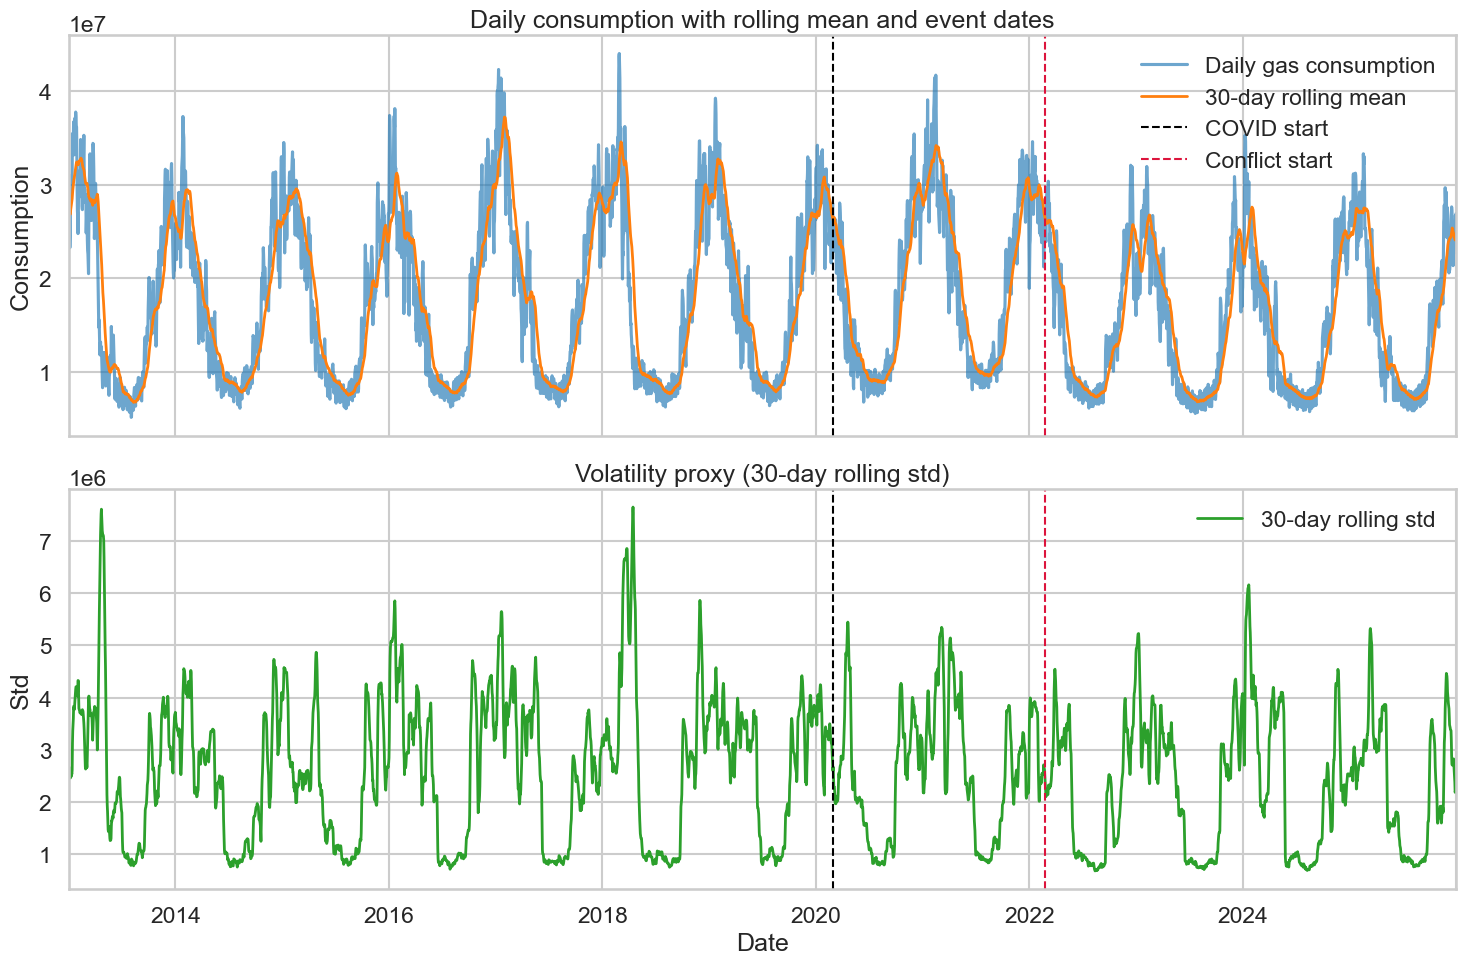

In [53]:
rolling_mean_30d = daily[TARGET_COL].rolling(30, min_periods=7).mean()
rolling_std_30d = daily[TARGET_COL].rolling(30, min_periods=7).std()

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

daily[TARGET_COL].plot(
    ax=axes[0], color="#1f77b4", alpha=0.65, label="Daily gas consumption"
)
rolling_mean_30d.plot(
    ax=axes[0], color="#ff7f0e", linewidth=2, label="30-day rolling mean"
)
axes[0].axvline(
    COVID_DATE, color="black", linestyle="--", linewidth=1.5, label="COVID start"
)
axes[0].axvline(
    CONFLICT_DATE,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="Conflict start",
)
axes[0].set_title("Daily consumption with rolling mean and event dates")
axes[0].set_ylabel("Consumption")
axes[0].legend(loc="upper right")

rolling_std_30d.plot(
    ax=axes[1], color="#2ca02c", linewidth=2, label="30-day rolling std"
)
axes[1].axvline(COVID_DATE, color="black", linestyle="--", linewidth=1.5)
axes[1].axvline(CONFLICT_DATE, color="crimson", linestyle="--", linewidth=1.5)
axes[1].set_title("Volatility proxy (30-day rolling std)")
axes[1].set_ylabel("Std")
axes[1].set_xlabel("Date")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

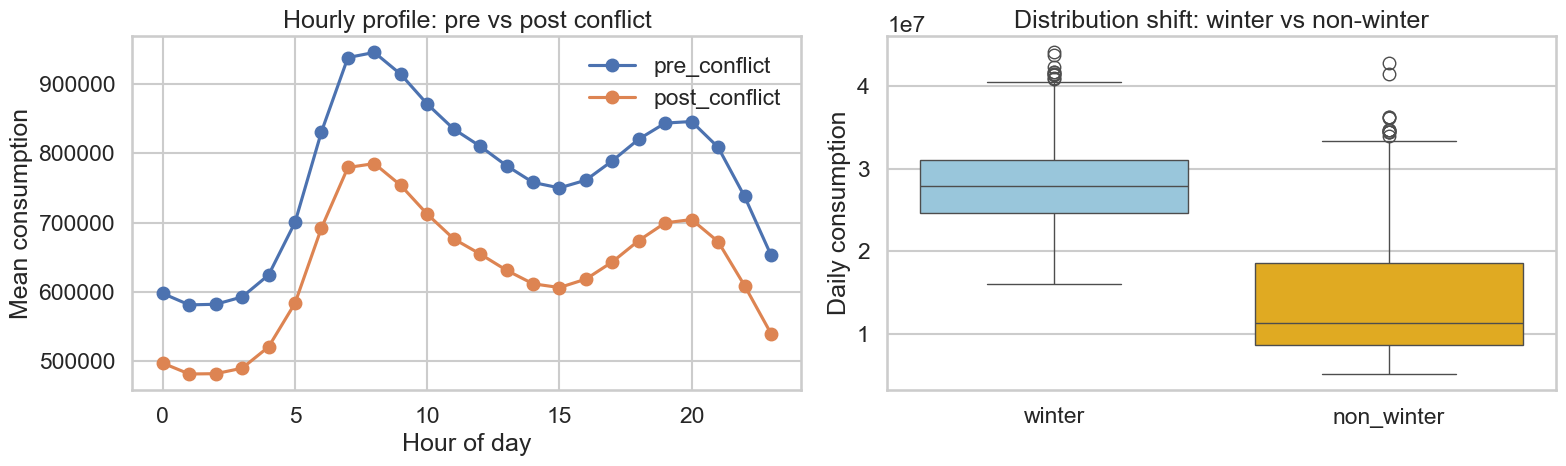

In [54]:
pre_conflict_hourly = df.loc[df.index < CONFLICT_DATE, TARGET_COL]
post_conflict_hourly = df.loc[df.index >= CONFLICT_DATE, TARGET_COL]

hourly_profile = pd.DataFrame(
    {
        "pre_conflict": pre_conflict_hourly.groupby(
            pre_conflict_hourly.index.hour
        ).mean(),
        "post_conflict": post_conflict_hourly.groupby(
            post_conflict_hourly.index.hour
        ).mean(),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_profile.plot(ax=axes[0], marker="o")
axes[0].set_title("Hourly profile: pre vs post conflict")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean consumption")

winter_label = np.where(daily.index.month.isin([12, 1, 2]), "winter", "non_winter")
box_df = pd.DataFrame({TARGET_COL: daily[TARGET_COL].values, "season": winter_label})
sns.boxplot(
    data=box_df, x="season", y=TARGET_COL, ax=axes[1], palette=["#8ecae6", "#ffb703"]
)
axes[1].set_title("Distribution shift: winter vs non-winter")
axes[1].set_xlabel("")
axes[1].set_ylabel("Daily consumption")

plt.tight_layout()
plt.show()

,segment,n_obs,adf_pvalue,kpss_pvalue
0,full,4748,0.000322,0.10
1,pre_covid,2616,0.001927,0.10
2,post_covid,2132,0.173937,0.10
3,pre_conflict,3341,0.001471,0.10
4,post_conflict,1407,0.193315,0.10
5,winter_only,1173,0.000050,0.01


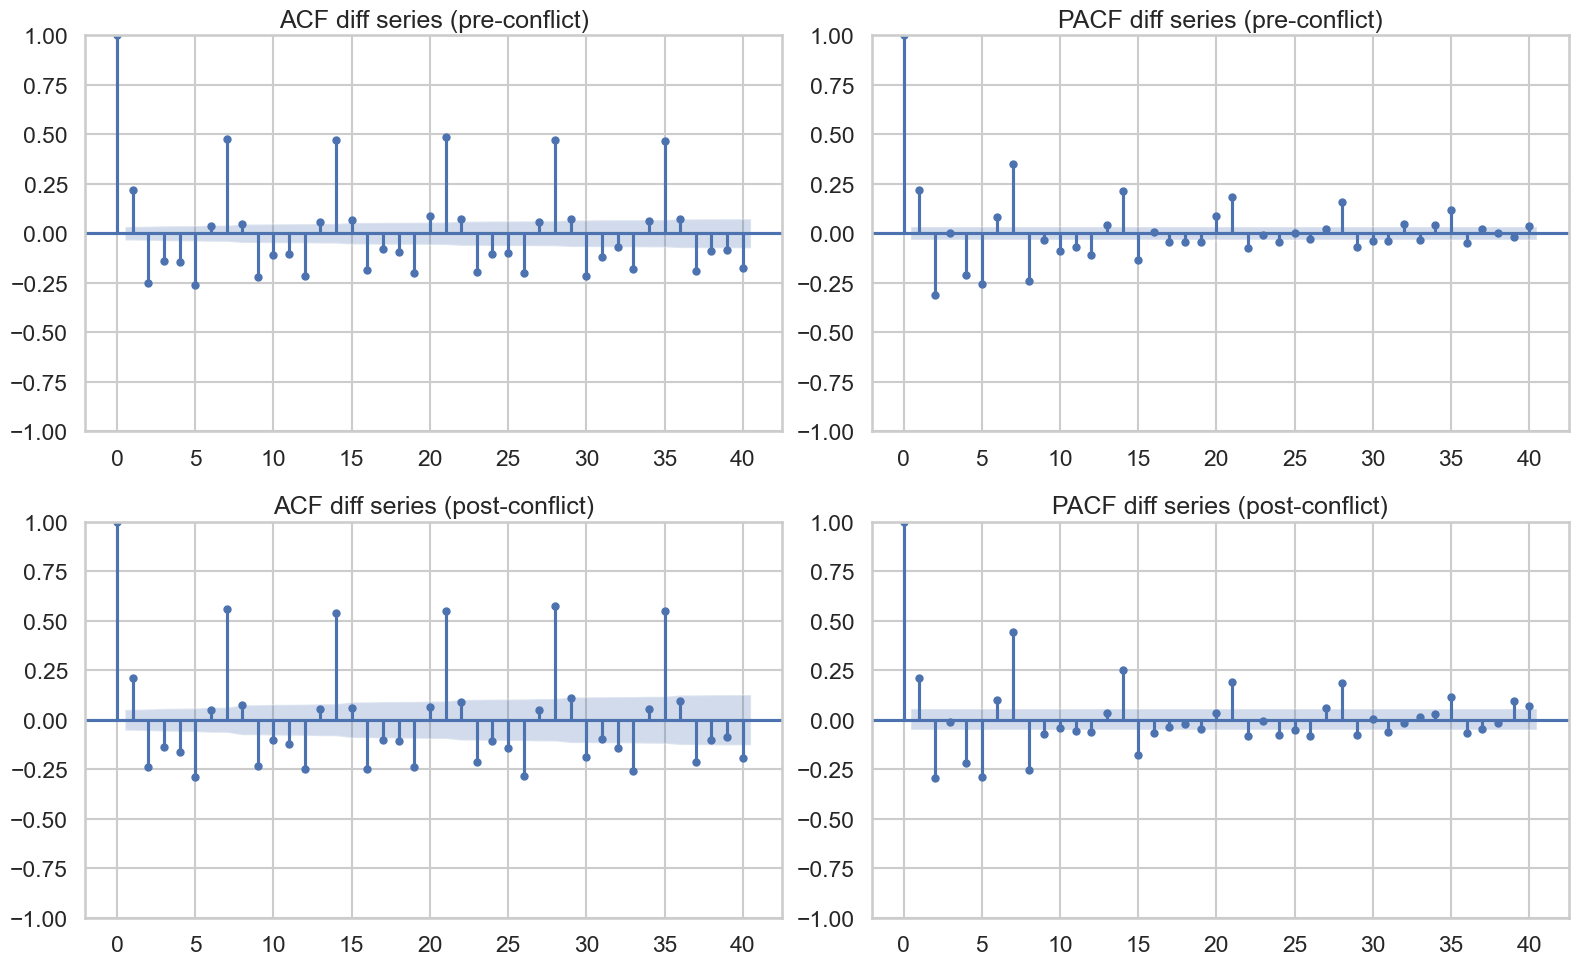

In [55]:
def run_stationarity_tests(series: pd.Series, label: str) -> dict:
    clean = series.dropna().astype(float)
    adf_stat, adf_pvalue, _, _, _, _ = adfuller(clean, regression="c", autolag="AIC")
    kpss_stat, kpss_pvalue, _, _ = kpss(clean, regression="c", nlags="auto")
    return {
        "segment": label,
        "n_obs": len(clean),
        "adf_pvalue": adf_pvalue,
        "kpss_pvalue": kpss_pvalue,
    }


segments = {
    "full": daily[TARGET_COL],
    "pre_covid": daily.loc[daily.index < COVID_DATE, TARGET_COL],
    "post_covid": daily.loc[daily.index >= COVID_DATE, TARGET_COL],
    "pre_conflict": daily.loc[daily.index < CONFLICT_DATE, TARGET_COL],
    "post_conflict": daily.loc[daily.index >= CONFLICT_DATE, TARGET_COL],
    "winter_only": daily.loc[daily.index.month.isin([12, 1, 2]), TARGET_COL],
}

stationarity_df = pd.DataFrame(
    [run_stationarity_tests(series, name) for name, series in segments.items()]
)
display(stationarity_df)

acf_pre = daily.loc[daily.index < CONFLICT_DATE, TARGET_COL].diff().dropna()
acf_post = daily.loc[daily.index >= CONFLICT_DATE, TARGET_COL].diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_acf(acf_pre, lags=40, ax=axes[0, 0], title="ACF diff series (pre-conflict)")
plot_pacf(
    acf_pre,
    lags=40,
    ax=axes[0, 1],
    method="ywm",
    title="PACF diff series (pre-conflict)",
)
plot_acf(acf_post, lags=40, ax=axes[1, 0], title="ACF diff series (post-conflict)")
plot_pacf(
    acf_post,
    lags=40,
    ax=axes[1, 1],
    method="ywm",
    title="PACF diff series (post-conflict)",
)
plt.tight_layout()
plt.show()

## SARIMAX: Baseline vs Intervention

Modeling uses daily aggregates for stable convergence and supervisor-facing interpretability.

- Baseline model: weather, price, holiday, and calendar controls.
- Intervention model: baseline + COVID/conflict/winter terms and interactions.

In [59]:
def smape(y_true: pd.Series, y_pred: pd.Series) -> float:
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    denom = np.abs(yt) + np.abs(yp)
    mask = denom > 1e-12
    return float(200.0 * np.mean(np.abs(yp[mask] - yt[mask]) / denom[mask]))


base_exog_cols = [
    "temperature_2m",
    "apparent_temperature",
    "weighted_avg_price_eur_mwh",
    "holiday",
    "before_holiday",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

event_exog_cols = base_exog_cols + [
    "post_covid",
    "post_conflict",
    "winter_month",
    "post_covid_x_winter",
    "post_conflict_x_winter",
]

candidate_orders = [
    ((1, 0, 1), (1, 1, 1, 7)),
    ((2, 0, 1), (1, 1, 1, 7)),
    ((1, 1, 1), (1, 1, 1, 7)),
]

train_mask = daily.index <= TRAIN_END
test_mask = (daily.index >= TEST_START) & (daily.index <= TEST_END)

y_train = daily.loc[train_mask, TARGET_COL]
y_test = daily.loc[test_mask, TARGET_COL]
y_train_log = np.log1p(y_train)

X_base_train = daily.loc[train_mask, base_exog_cols]
X_base_test = daily.loc[test_mask, base_exog_cols]
X_event_train = daily.loc[train_mask, event_exog_cols]
X_event_test = daily.loc[test_mask, event_exog_cols]

fits = []
for order, seasonal_order in candidate_orders:
    try:
        model = SARIMAX(
            endog=y_train_log,
            exog=X_base_train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        result = model.fit(disp=False, maxiter=150)
        fits.append(
            {
                "order": order,
                "seasonal_order": seasonal_order,
                "aic": float(result.aic),
                "bic": float(result.bic),
                "result": result,
            }
        )
    except Exception as exc:
        fits.append(
            {
                "order": order,
                "seasonal_order": seasonal_order,
                "aic": np.nan,
                "bic": np.nan,
                "result": None,
                "error": str(exc),
            }
        )

model_search_df = pd.DataFrame(
    [{k: v for k, v in row.items() if k != "result"} for row in fits]
)
display(model_search_df)

valid_fits = [row for row in fits if row["result"] is not None]
assert valid_fits, "No baseline SARIMAX candidate converged."
best_fit = sorted(valid_fits, key=lambda x: x["aic"])[0]

best_order = best_fit["order"]
best_seasonal_order = best_fit["seasonal_order"]
base_result = best_fit["result"]

intervention_model = SARIMAX(
    endog=y_train_log,
    exog=X_event_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
intervention_result = intervention_model.fit(disp=False, maxiter=150)

base_forecast_log = base_result.get_forecast(
    steps=len(y_test), exog=X_base_test
).predicted_mean
event_forecast_log = intervention_result.get_forecast(
    steps=len(y_test), exog=X_event_test
).predicted_mean

base_forecast = pd.Series(
    np.expm1(base_forecast_log), index=y_test.index, name="baseline_forecast"
).clip(lower=0)
event_forecast = pd.Series(
    np.expm1(event_forecast_log), index=y_test.index, name="intervention_forecast"
).clip(lower=0)

winter_test_mask = y_test.index.month.isin([12, 1, 2])


def metric_block(y_true: pd.Series, y_pred: pd.Series, label: str) -> dict:
    return {
        "model": label,
        "mae_full_test": float(mean_absolute_error(y_true, y_pred)),
        "smape_full_test": smape(y_true, y_pred),
        "mae_winter_test": float(
            mean_absolute_error(y_true[winter_test_mask], y_pred[winter_test_mask])
        ),
        "smape_winter_test": smape(y_true[winter_test_mask], y_pred[winter_test_mask]),
    }


metrics_df = pd.DataFrame(
    [
        metric_block(y_test, base_forecast, "baseline"),
        metric_block(y_test, event_forecast, "intervention"),
    ]
)
display(metrics_df)

lb_base = acorr_ljungbox(base_result.resid.dropna(), lags=[10, 20], return_df=True)
lb_event = acorr_ljungbox(
    intervention_result.resid.dropna(), lags=[10, 20], return_df=True
)
print("Ljung-Box baseline (log-scale residuals)")
display(lb_base)
print("Ljung-Box intervention (log-scale residuals)")
display(lb_event)

coef_table = pd.DataFrame(
    {"coef": intervention_result.params, "pvalue": intervention_result.pvalues}
)
event_terms = [
    "post_covid",
    "post_conflict",
    "winter_month",
    "post_covid_x_winter",
    "post_conflict_x_winter",
]
event_coef_df = coef_table.loc[coef_table.index.isin(event_terms)].sort_index().copy()
event_coef_df["approx_pct_effect"] = 100.0 * (np.exp(event_coef_df["coef"]) - 1.0)
display(event_coef_df)

print(f"Best order: {best_order}, seasonal: {best_seasonal_order}")

,order,seasonal_order,aic,bic
0,"(1, 0, 1)","(1, 1, 1, 7)",-12849.117816,-12754.703321
1,"(2, 0, 1)","(1, 1, 1, 7)",-12837.755802,-12737.047009
2,"(1, 1, 1)","(1, 1, 1, 7)",-12826.181198,-12731.770453


,model,mae_full_test,smape_full_test,mae_winter_test,smape_winter_test
0,baseline,4.761899e+06,34.946926,4.187846e+06,17.951602
1,intervention,4.863991e+06,35.697809,3.858634e+06,16.306188


Ljung-Box baseline (log-scale residuals)


,lb_stat,lb_pvalue
10,1170.295178,3.676676e-245
20,1171.390837,9.810897e-236


Ljung-Box intervention (log-scale residuals)


,lb_stat,lb_pvalue
10,1179.903658,3.113010e-247
20,1180.906319,9.057664e-238


,coef,pvalue,approx_pct_effect
post_conflict,-0.003017,0.987517,-0.301222
post_conflict_x_winter,0.018432,0.814337,1.860253
post_covid,-0.060589,0.579857,-5.879004
post_covid_x_winter,-0.027510,0.570215,-2.713549
winter_month,-0.007373,0.700522,-0.734546


Best order: (1, 0, 1), seasonal: (1, 1, 1, 7)


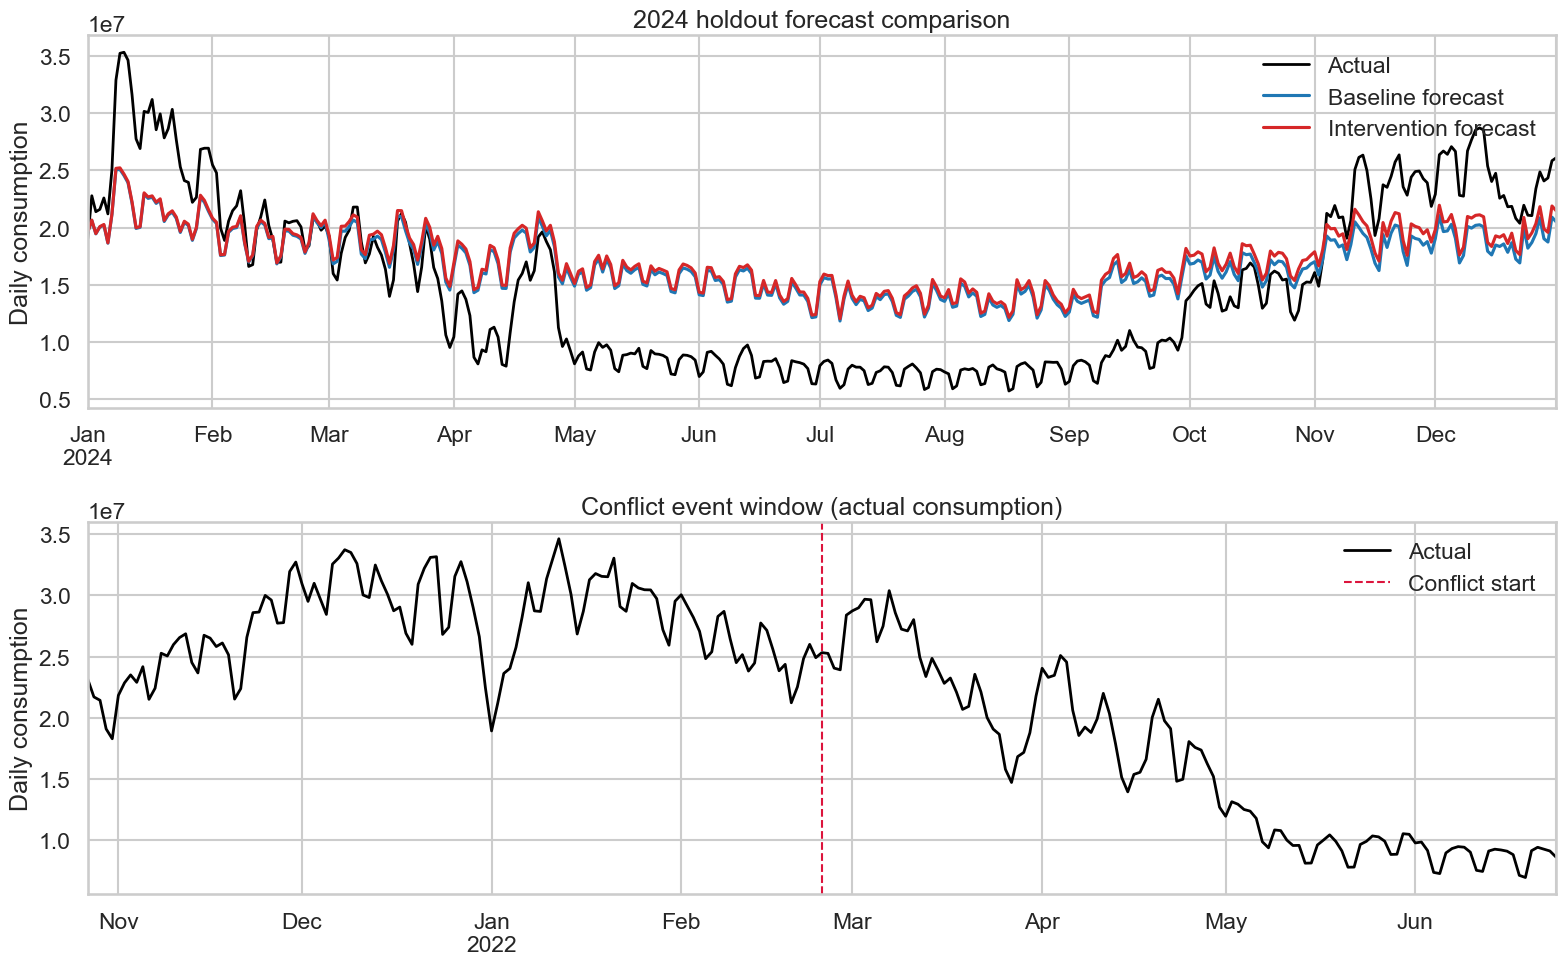

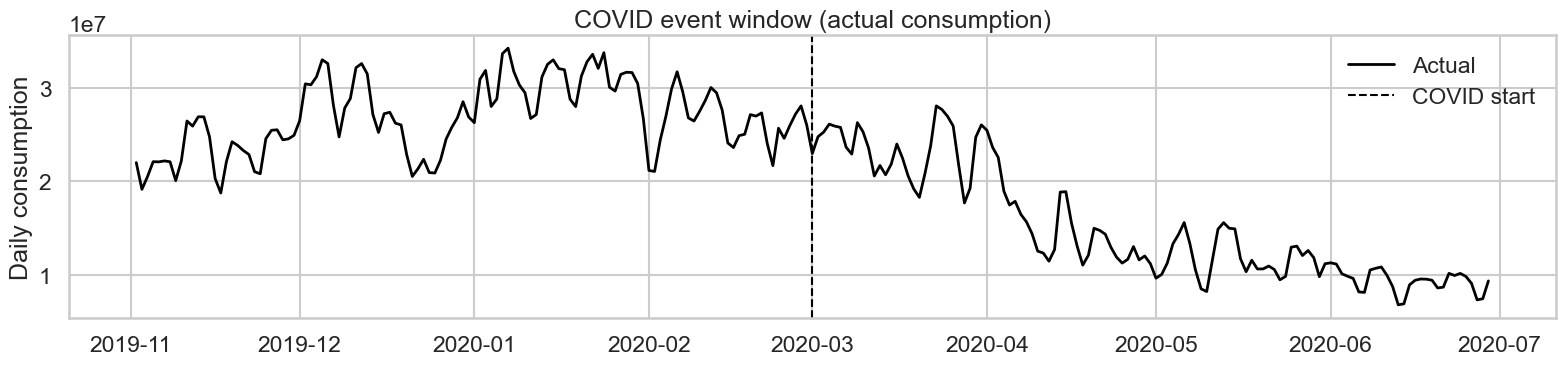

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

y_test.plot(ax=axes[0], color="black", linewidth=2, label="Actual")
base_forecast.plot(ax=axes[0], color="#1f77b4", label="Baseline forecast")
event_forecast.plot(ax=axes[0], color="#d62728", label="Intervention forecast")
axes[0].set_title("2024 holdout forecast comparison")
axes[0].set_ylabel("Daily consumption")
axes[0].legend(loc="upper right")

window_days = 120
conflict_slice = daily.loc[
    (daily.index >= CONFLICT_DATE - pd.Timedelta(days=window_days))
    & (daily.index <= CONFLICT_DATE + pd.Timedelta(days=window_days))
]
conflict_slice[TARGET_COL].plot(ax=axes[1], color="black", linewidth=2, label="Actual")
axes[1].axvline(
    CONFLICT_DATE,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="Conflict start",
)
axes[1].set_title("Conflict event window (actual consumption)")
axes[1].set_ylabel("Daily consumption")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

covid_slice = daily.loc[
    (daily.index >= COVID_DATE - pd.Timedelta(days=window_days))
    & (daily.index <= COVID_DATE + pd.Timedelta(days=window_days))
]
plt.figure(figsize=(16, 4))
plt.plot(
    covid_slice.index,
    covid_slice[TARGET_COL],
    color="black",
    linewidth=2,
    label="Actual",
)
plt.axvline(
    COVID_DATE, color="black", linestyle="--", linewidth=1.5, label="COVID start"
)
plt.title("COVID event window (actual consumption)")
plt.ylabel("Daily consumption")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [61]:
insight_rows = []
for term in [
    "post_covid",
    "post_conflict",
    "winter_month",
    "post_covid_x_winter",
    "post_conflict_x_winter",
]:
    if term not in event_coef_df.index:
        continue
    coef = float(event_coef_df.loc[term, "coef"])
    pval = float(event_coef_df.loc[term, "pvalue"])
    pct_effect = float(event_coef_df.loc[term, "approx_pct_effect"])
    direction = "increase" if coef > 0 else "decrease"
    significant = "yes" if pval < 0.05 else "no"
    insight_rows.append(
        {
            "term": term,
            "coef_log_scale": coef,
            "approx_pct_effect": pct_effect,
            "pvalue": pval,
            "significant_5pct": significant,
            "direction": direction,
        }
    )

insights_df = pd.DataFrame(insight_rows).sort_values("pvalue")
display(insights_df)

print("Interpretation guide")
print(
    "- approx_pct_effect uses exp(coef)-1 because SARIMAX was fit on log(1 + consumption)"
)
print("- post_conflict: persistent level shift after 2022-02-24")
print("- winter_month: average winter effect vs non-winter months")
print("- post_conflict_x_winter: extra winter effect after conflict")
print("- If p-value < 0.05, the effect is statistically significant in this model")

,term,coef_log_scale,approx_pct_effect,pvalue,significant_5pct,direction
3,post_covid_x_winter,-0.027510,-2.713549,0.570215,no,decrease
0,post_covid,-0.060589,-5.879004,0.579857,no,decrease
2,winter_month,-0.007373,-0.734546,0.700522,no,decrease
4,post_conflict_x_winter,0.018432,1.860253,0.814337,no,increase
1,post_conflict,-0.003017,-0.301222,0.987517,no,decrease


Interpretation guide
- approx_pct_effect uses exp(coef)-1 because SARIMAX was fit on log(1 + consumption)
- post_conflict: persistent level shift after 2022-02-24
- winter_month: average winter effect vs non-winter months
- post_conflict_x_winter: extra winter effect after conflict
- If p-value < 0.05, the effect is statistically significant in this model
